In [22]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [23]:
# 현재 최대 행/열 출력 제한 확인
print(f"현재 최대 행 수: {pd.get_option('display.max_rows')}")
print(f"현재 최대 열 수: {pd.get_option('display.max_columns')}")

# 제한 없이 출력하도록 설정 변경 (None은 제한 없음을 의미)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # 컬럼 너비 제한 해제

현재 최대 행 수: 100
현재 최대 열 수: None


In [24]:
# 데이터 로드
user_df = pd.read_csv('../../data/processed/01_user_profile_preprocessed_v2.csv')
event_df = pd.read_csv('../../data/processed/02_event_log_preprocessed_v2.csv')

print("="*60)
print("데이터 로드 완료!")
print("="*60)
print(f"\nuser_df: {user_df.shape}")
print(f"event_df: {event_df.shape}")


데이터 로드 완료!

user_df: (12500, 23)
event_df: (1757262, 17)


In [25]:
# ============================================================
# 컬럼명/날짜 파생컬럼 확인 및 보정
# ============================================================

# 날짜 컬럼 datetime 변환
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# event_month 컬럼이 없으면 event_time에서 생성
if "event_month" not in event_df.columns:
    event_df["event_month"] = event_df["event_time"].dt.to_period("M").astype(str)

# event_weekday 컬럼이 없으면 생성
weekday_map = {
    0: "월",
    1: "화",
    2: "수",
    3: "목",
    4: "금",
    5: "토",
    6: "일"
}

if "event_weekday" not in event_df.columns:
    event_df["event_weekday"] = event_df["event_time"].dt.dayofweek.map(weekday_map)

# event_hour 컬럼이 없으면 생성
if "event_hour" not in event_df.columns:
    event_df["event_hour"] = event_df["event_time"].dt.hour

# 로그 장애 기간 플래그가 없으면 생성
if "is_log_issue_period" not in event_df.columns:
    LOG_ISSUE_START = pd.Timestamp("2025-03-10")
    LOG_ISSUE_END = pd.Timestamp("2025-03-14 23:59:59")
    event_df["is_log_issue_period"] = event_df["event_time"].between(
        LOG_ISSUE_START,
        LOG_ISSUE_END
    )

print("event_df 주요 컬럼 확인:")
print([col for col in ["user_id", "event_time", "event_type", "event_month", "event_weekday", "event_hour", "is_log_issue_period"] if col in event_df.columns])


event_df 주요 컬럼 확인:
['user_id', 'event_time', 'event_type', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']


---
# 추가 검증
### 알림 오픈 전 행동량 비교
- 챌린지 알림을 받은 유저 중
- 나중에 챌린지 알림을 연 유저와 열지 않은 유저를 나누고
- 첫 챌린지 알림 수신 이전의 활동량을 비교
    - '오픈전'을 그대로 쓰면 유저맏 오픈까지 걸린 시간이 달라서 활동량이 과대평가 될 수 있음
    - -> '첫 챌린지 알림 수신' 시점으로 잡음

In [26]:
print(event_df.columns.tolist())
print(user_df.columns.tolist())

['user_id', 'event_time', 'event_type', 'session_id', 'notification_type', 'is_event_type_missing', 'event_type_display', 'is_notification_event', 'is_session_id_missing', 'is_session_missing_expected', 'is_session_missing_unexpected', 'notification_type_display', 'event_date', 'event_month', 'event_weekday', 'event_hour', 'is_log_issue_period']
['user_id', 'signup_date', 'signup_channel', 'device', 'notification_agreed', 'notification_changed_date', 'signup_day', 'signup_month', 'signup_weekday', 'first_event_time', 'first_event_elapsed_hours', 'first_app_launch_time', 'app_launch_elapsed_hours', 'onboarding_completed_time', 'onboarding_elapsed_hours', 'app_launch_to_onboarding_hours', 'is_onboarding_completed', 'event_count_total', 'avg_events_per_session', 'is_signup_log_issue_period', 'is_no_event_user', 'is_notification_changed', 'is_first_event_before_signup']


In [27]:
print("[Event_Type 목록]")
display(event_df["event_type"].value_counts(dropna=False))

print("[notification_type 목록]")
display(event_df["notification_type"].value_counts(dropna=False))

[Event_Type 목록]


event_type
앱실행       728657
수면기록      242978
알림수신      194324
운동기록      131269
마음챙김      130344
식단기록      101366
챌린지참여      96829
챌린지_탐색     78101
NaN        26456
알림오픈       21219
온보딩_완료      5719
Name: count, dtype: int64

[notification_type 목록]


notification_type
NaN       1538380
리마인드        85830
광고성         78262
챌린지_알림      54790
Name: count, dtype: int64

In [29]:
ct = pd.crosstab(
    event_df["event_type"].fillna("Missing"),
    event_df["notification_type"].fillna("Missing"),
    margins=True
)

display(ct)

notification_type,Missing,광고성,리마인드,챌린지_알림,All
event_type,,,,,
Missing,23117,1203,1275,861,26456
마음챙김,130344,0,0,0,130344
수면기록,242978,0,0,0,242978
식단기록,101366,0,0,0,101366
알림수신,0,74958,73667,45699,194324
알림오픈,0,2101,10888,8230,21219
앱실행,728657,0,0,0,728657
온보딩_완료,5719,0,0,0,5719
운동기록,131269,0,0,0,131269


In [35]:
print("[notification_type 실제 고유값]")
for x in event_df["notification_type"].dropna().unique():
    print(repr(x))

print("\n[event_type 실제 고유값]")
for x in event_df["event_type"].dropna().unique():
    print(repr(x))

[notification_type 실제 고유값]
'광고성'
'리마인드'
'챌린지_알림'

[event_type 실제 고유값]
'앱실행'
'온보딩_완료'
'챌린지_탐색'
'챌린지참여'
'알림수신'
'운동기록'
'마음챙김'
'수면기록'
'식단기록'
'알림오픈'


In [36]:
# 조건별 개수 확인
mask_challenge = event_df["notification_type"] == "챌린지_알림"
mask_receive_open = event_df["event_type"].isin(["알림수신", "알림오픈"])

print("챌린지_알림 개수:", mask_challenge.sum())
print("알림수신/알림오픈 개수:", mask_receive_open.sum())
print("둘 다 만족하는 개수:", (mask_challenge & mask_receive_open).sum())

챌린지_알림 개수: 54790
알림수신/알림오픈 개수: 215543
둘 다 만족하는 개수: 53929


In [37]:
challenge_noti = event_df[
    (event_df["notification_type"] == "챌린지_알림")
    & (event_df["event_type"].isin(["알림수신", "알림오픈"]))
].copy()

print("챌린지 알림 수신/오픈 이벤트 수:", len(challenge_noti))

display(
    challenge_noti[
        ["user_id", "event_time", "event_type", "notification_type"]
    ].head()
)

챌린지 알림 수신/오픈 이벤트 수: 53929


,user_id,event_time,event_type,notification_type
75,U0000001,2025-01-31 12:12:00,알림수신,챌린지_알림
111,U0000001,2025-02-04 19:43:00,알림수신,챌린지_알림
135,U0000001,2025-02-09 17:06:00,알림수신,챌린지_알림
147,U0000001,2025-02-11 12:29:00,알림수신,챌린지_알림
172,U0000001,2025-02-15 16:57:00,알림수신,챌린지_알림


In [38]:
# 오픈율 확인

challenge_open_summary = (
    challenge_noti
    .groupby("event_type")
    .size()
    .reset_index(name="event_count")
)

display(challenge_open_summary)

challenge_receive_count = (challenge_noti["event_type"] == "알림수신").sum()
challenge_open_count = (challenge_noti["event_type"] == "알림오픈").sum()

challenge_open_rate = challenge_open_count / challenge_receive_count

print("챌린지 알림 수신 수:", challenge_receive_count)
print("챌린지 알림 오픈 수:", challenge_open_count)
print("챌린지 알림 오픈율:", round(challenge_open_rate, 4))

,event_type,event_count
0,알림수신,45699
1,알림오픈,8230


챌린지 알림 수신 수: 45699
챌린지 알림 오픈 수: 8230
챌린지 알림 오픈율: 0.1801


In [39]:
# 첫 챌린지 알림 수신 시점
first_challenge_receive = (
    challenge_noti[challenge_noti["event_type"] == "알림수신"]
    .groupby("user_id")["event_time"]
    .min()
    .reset_index(name="first_challenge_receive_time")
)

# 첫 챌린지 알림 오픈 시점
first_challenge_open = (
    challenge_noti[challenge_noti["event_type"] == "알림오픈"]
    .groupby("user_id")["event_time"]
    .min()
    .reset_index(name="first_challenge_open_time")
)

# 챌린지 알림 수신 유저 기준으로 병합
challenge_user = first_challenge_receive.merge(
    first_challenge_open,
    on="user_id",
    how="left"
)

challenge_user["opened_challenge_notification"] = (
    challenge_user["first_challenge_open_time"].notna()
)

print("챌린지 알림 수신 유저 수:", len(challenge_user))
print("챌린지 알림 오픈 유저 수:", challenge_user["opened_challenge_notification"].sum())
print("챌린지 알림 미오픈 유저 수:", (~challenge_user["opened_challenge_notification"]).sum())

display(challenge_user.head())

챌린지 알림 수신 유저 수: 6228
챌린지 알림 오픈 유저 수: 3651
챌린지 알림 미오픈 유저 수: 2577


,user_id,first_challenge_receive_time,first_challenge_open_time,opened_challenge_notification
0,U0000001,2025-01-31 12:12:00,2025-02-21 12:59:00,True
1,U0000004,2025-02-25 10:53:00,2025-02-25 11:03:00,True
2,U0000005,2025-02-24 20:51:00,2025-04-06 10:31:00,True
3,U0000011,2025-03-09 15:43:00,2025-04-10 14:17:00,True
4,U0000013,2025-01-11 18:29:00,NaT,False


In [40]:
# 첫 오픈 시간이 첫 수신보다 빠른 케이스 탐색

challenge_user["open_before_receive"] = (
    challenge_user["first_challenge_open_time"].notna()
    & (challenge_user["first_challenge_open_time"] < challenge_user["first_challenge_receive_time"])
)

print(
    "첫 챌린지 알림 오픈이 첫 수신보다 빠른 유저 수:",
    challenge_user["open_before_receive"].sum()
)

첫 챌린지 알림 오픈이 첫 수신보다 빠른 유저 수: 19


전체 챌린지 알림 수신 유저 중   
첫 오픈 시간이 첫 수신 시간보다 빠른 19명은     
로그 순서 이상 케이스로 판단, 본 분석에서는 제외

In [41]:
# 첫 오픈 시간이 첫 수신보다 빠른 이상 케이스 플래그
challenge_user["open_before_receive"] = (
    challenge_user["first_challenge_open_time"].notna()
    & (challenge_user["first_challenge_open_time"] < challenge_user["first_challenge_receive_time"])
)

print("전체 챌린지 알림 수신 유저 수:", len(challenge_user))
print("첫 오픈이 첫 수신보다 빠른 유저 수:", challenge_user["open_before_receive"].sum())
print(
    "제외 비율:",
    round(challenge_user["open_before_receive"].mean() * 100, 3),
    "%"
)

# 메인 분석용 클린 데이터
challenge_user_clean = challenge_user[
    ~challenge_user["open_before_receive"]
].copy()

print("분석 대상 유저 수:", len(challenge_user_clean))

전체 챌린지 알림 수신 유저 수: 6228
첫 오픈이 첫 수신보다 빠른 유저 수: 19
제외 비율: 0.305 %
분석 대상 유저 수: 6209


In [ ]:
event_with_challenge_time = event_df.merge(
    challenge_user_clean[
        ["user_id", "first_challenge_receive_time", "opened_challenge_notification"]
    ],
    on="user_id",
    how="inner"     # 챌린지 알림 받은 유저들의 이벤트만 분석
)

print("머지 후 이벤트 수:", len(event_with_challenge_time))
display(event_with_challenge_time.head())

머지 후 이벤트 수: 1161815


,user_id,event_time,event_type,session_id,notification_type,is_event_type_missing,event_type_display,is_notification_event,is_session_id_missing,is_session_missing_expected,is_session_missing_unexpected,notification_type_display,event_date,event_month,event_weekday,event_hour,is_log_issue_period,first_challenge_receive_time,opened_challenge_notification
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,False,앱실행,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-31 12:12:00,True
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,False,온보딩_완료,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-31 12:12:00,True
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,False,챌린지_탐색,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-31 12:12:00,True
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,False,챌린지참여,False,False,False,False,비알림,2025-01-25,2025-01,토,7,False,2025-01-31 12:12:00,True
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,False,알림수신,True,True,True,False,광고성,2025-01-25,2025-01,토,20,False,2025-01-31 12:12:00,True


In [44]:
# 첫 챌린지 알림 수신 이전 이벤트만 추출
pre_event = event_with_challenge_time[
    event_with_challenge_time["event_time"]
    < event_with_challenge_time["first_challenge_receive_time"]
].copy()

print("첫 챌린지 알림 수신 이전 전체 이벤트 수:", len(pre_event))

display(
    pre_event[
        [
            "user_id",
            "event_time",
            "event_type",
            "notification_type",
            "first_challenge_receive_time",
            "opened_challenge_notification"
        ]
    ].head()
)

첫 챌린지 알림 수신 이전 전체 이벤트 수: 133219


,user_id,event_time,event_type,notification_type,first_challenge_receive_time,opened_challenge_notification
0,U0000001,2025-01-25 07:25:45,앱실행,NaN,2025-01-31 12:12:00,True
1,U0000001,2025-01-25 07:26:15,온보딩_완료,NaN,2025-01-31 12:12:00,True
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,NaN,2025-01-31 12:12:00,True
3,U0000001,2025-01-25 07:27:55,챌린지참여,NaN,2025-01-31 12:12:00,True
4,U0000001,2025-01-25 20:30:00,알림수신,광고성,2025-01-31 12:12:00,True


In [45]:
# 앱 내 행동에서 알림 이벤트 제외
pre_core_event = pre_event[
    ~pre_event["event_type"].isin(["알림수신", "알림오픈"])
].copy()

print("첫 챌린지 알림 수신 이전 앱 내 행동 이벤트 수:", len(pre_core_event))

display(
    pre_core_event[
        ["user_id", "event_time", "event_type", "session_id", "opened_challenge_notification"]
    ].head()
)

첫 챌린지 알림 수신 이전 앱 내 행동 이벤트 수: 119104


,user_id,event_time,event_type,session_id,opened_challenge_notification
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,True
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,True
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,True
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,True
5,U0000001,2025-01-26 10:51:54,앱실행,b57046502f,True


In [46]:
# 이벤트 날짜 생성
pre_core_event["event_date"] = pre_core_event["event_time"].dt.date

# 유저별 사전 행동량 집계
pre_activity = (
    pre_core_event
    .groupby("user_id")
    .agg(
        pre_event_count=("event_type", "count"),
        pre_active_days=("event_date", "nunique"),
        pre_session_count=("session_id", "nunique"),
        pre_app_launch_count=("event_type", lambda x: (x == "앱실행").sum()),
        pre_challenge_explore_count=("event_type", lambda x: (x == "챌린지_탐색").sum()),
        pre_challenge_join_count=("event_type", lambda x: (x == "챌린지참여").sum()),
    )
    .reset_index()
)

display(pre_activity.head())

,user_id,pre_event_count,pre_active_days,pre_session_count,pre_app_launch_count,pre_challenge_explore_count,pre_challenge_join_count
0,U0000001,68,7,23,23,13,15
1,U0000004,9,2,4,4,0,0
2,U0000005,30,7,16,16,1,1
3,U0000011,111,13,58,59,2,2
4,U0000013,19,4,11,11,1,1


In [47]:
pre_activity_user = challenge_user_clean.merge(
    pre_activity,
    on="user_id",
    how="left"
)

# 첫 챌린지 알림 수신 이전 앱 내 행동이 없던 유저는 0으로 채우기
count_cols = [
    "pre_event_count",
    "pre_active_days",
    "pre_session_count",
    "pre_app_launch_count",
    "pre_challenge_explore_count",
    "pre_challenge_join_count"
]

pre_activity_user[count_cols] = pre_activity_user[count_cols].fillna(0)

# 사전 챌린지 경험 여부
pre_activity_user["pre_has_challenge_explore"] = (
    pre_activity_user["pre_challenge_explore_count"] > 0
)

pre_activity_user["pre_has_challenge_join"] = (
    pre_activity_user["pre_challenge_join_count"] > 0
)

display(pre_activity_user.head())

,user_id,first_challenge_receive_time,first_challenge_open_time,opened_challenge_notification,open_before_receive,pre_event_count,pre_active_days,pre_session_count,pre_app_launch_count,pre_challenge_explore_count,pre_challenge_join_count,pre_has_challenge_explore,pre_has_challenge_join
0,U0000001,2025-01-31 12:12:00,2025-02-21 12:59:00,True,False,68.0,7.0,23.0,23.0,13.0,15.0,True,True
1,U0000004,2025-02-25 10:53:00,2025-02-25 11:03:00,True,False,9.0,2.0,4.0,4.0,0.0,0.0,False,False
2,U0000005,2025-02-24 20:51:00,2025-04-06 10:31:00,True,False,30.0,7.0,16.0,16.0,1.0,1.0,True,True
3,U0000011,2025-03-09 15:43:00,2025-04-10 14:17:00,True,False,111.0,13.0,58.0,59.0,2.0,2.0,True,True
4,U0000013,2025-01-11 18:29:00,NaT,False,False,19.0,4.0,11.0,11.0,1.0,1.0,True,True


In [48]:
# 오픈 유저 vs 미오픈 유저 비교표

summary = (
    pre_activity_user
    .groupby("opened_challenge_notification")
    .agg(
        user_count=("user_id", "count"),
        
        avg_pre_event_count=("pre_event_count", "mean"),
        median_pre_event_count=("pre_event_count", "median"),
        
        avg_pre_active_days=("pre_active_days", "mean"),
        median_pre_active_days=("pre_active_days", "median"),
        
        avg_pre_session_count=("pre_session_count", "mean"),
        median_pre_session_count=("pre_session_count", "median"),
        
        avg_pre_app_launch_count=("pre_app_launch_count", "mean"),
        median_pre_app_launch_count=("pre_app_launch_count", "median"),
        
        pre_challenge_explore_rate=("pre_has_challenge_explore", "mean"),
        pre_challenge_join_rate=("pre_has_challenge_join", "mean")
    )
    .reset_index()
)

summary["group"] = summary["opened_challenge_notification"].map({
    True: "챌린지 알림 오픈",
    False: "챌린지 알림 미오픈"
})

# 비율 컬럼 보기 좋게 변환
summary["pre_challenge_explore_rate"] = summary["pre_challenge_explore_rate"] * 100
summary["pre_challenge_join_rate"] = summary["pre_challenge_join_rate"] * 100

display(summary)

,opened_challenge_notification,user_count,avg_pre_event_count,median_pre_event_count,avg_pre_active_days,median_pre_active_days,avg_pre_session_count,median_pre_session_count,avg_pre_app_launch_count,median_pre_app_launch_count,pre_challenge_explore_rate,pre_challenge_join_rate,group
0,False,2577,16.438882,10.0,2.744276,2.0,7.311603,5.0,7.237485,5.0,43.733023,45.750873,챌린지 알림 미오픈
1,True,3632,20.580396,12.0,2.855176,2.0,8.632434,5.0,8.535793,5.0,57.020925,59.223568,챌린지 알림 오픈


<Figure size 600x400 with 0 Axes>

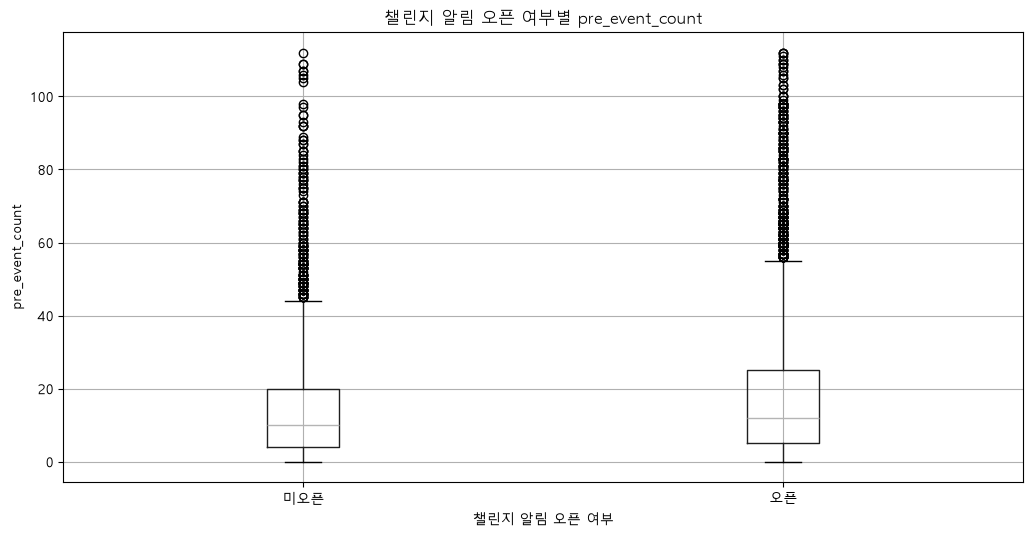

<Figure size 600x400 with 0 Axes>

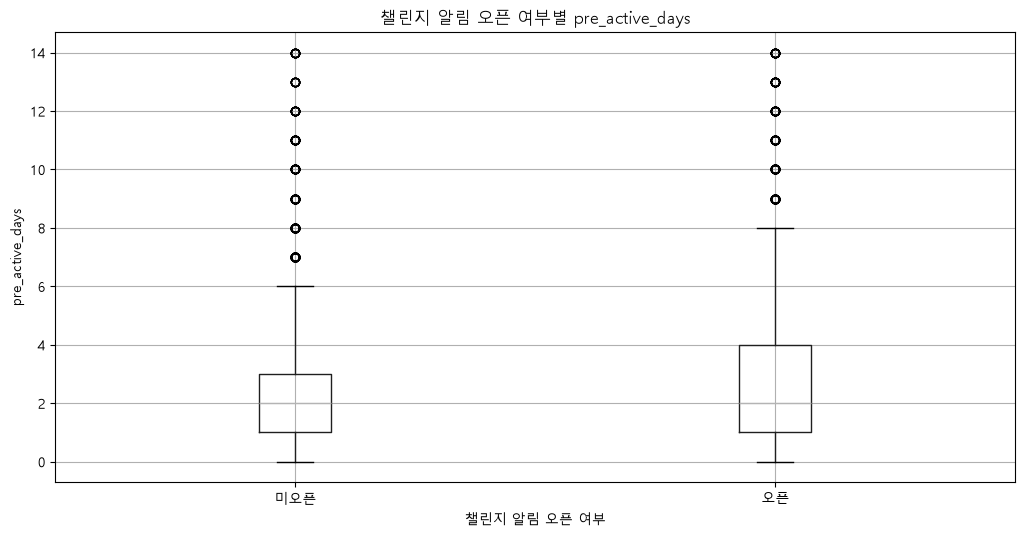

<Figure size 600x400 with 0 Axes>

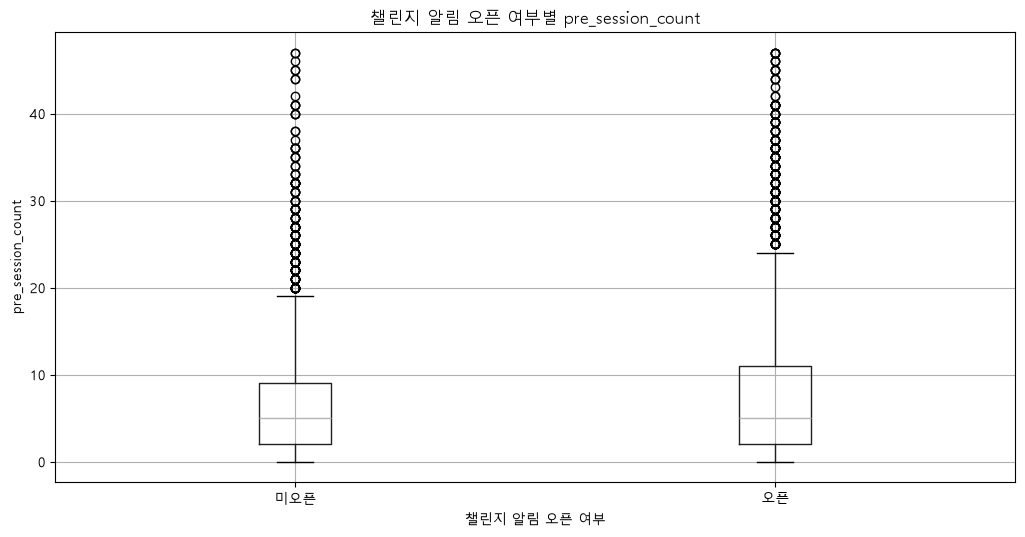

<Figure size 600x400 with 0 Axes>

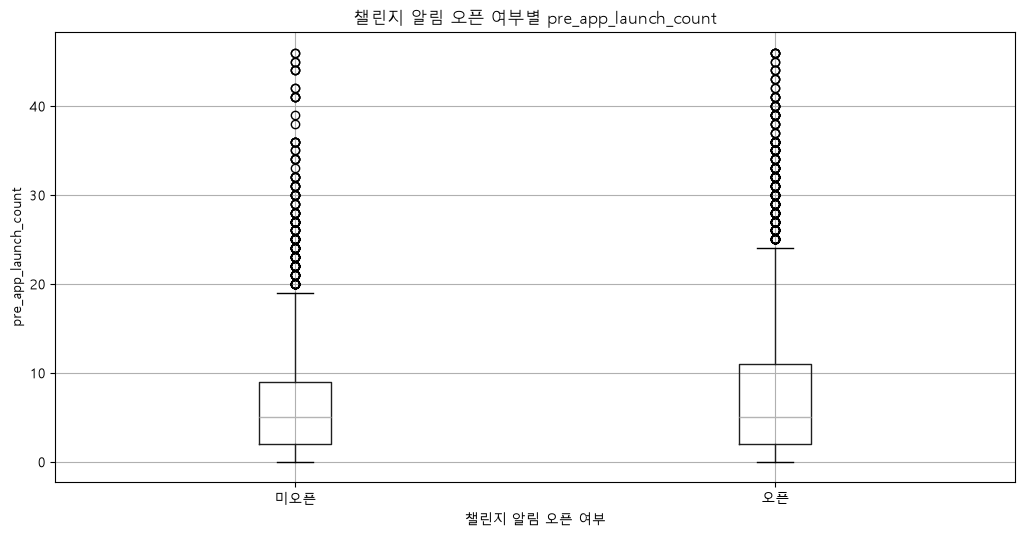

In [49]:
plot_df = pre_activity_user.copy()

plot_df["group"] = plot_df["opened_challenge_notification"].map({
    True: "오픈",
    False: "미오픈"
})

metrics = [
    "pre_event_count",
    "pre_active_days",
    "pre_session_count",
    "pre_app_launch_count"
]

for metric in metrics:
    cap = plot_df[metric].quantile(0.99)
    temp = plot_df[plot_df[metric] <= cap]

    plt.figure(figsize=(6, 4))
    temp.boxplot(column=metric, by="group")
    plt.title(f"챌린지 알림 오픈 여부별 {metric}")
    plt.suptitle("")
    plt.xlabel("챌린지 알림 오픈 여부")
    plt.ylabel(metric)
    plt.show()

In [50]:
opened = pre_activity_user[
    pre_activity_user["opened_challenge_notification"] == True
]

not_opened = pre_activity_user[
    pre_activity_user["opened_challenge_notification"] == False
]

def rank_biserial_from_u(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

test_metrics = [
    "pre_event_count",
    "pre_active_days",
    "pre_session_count",
    "pre_app_launch_count",
    "pre_challenge_explore_count",
    "pre_challenge_join_count"
]

test_results = []

for metric in test_metrics:
    x = opened[metric]
    y = not_opened[metric]
    
    u_stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
    rbc = rank_biserial_from_u(u_stat, len(x), len(y))
    
    test_results.append({
        "metric": metric,
        "opened_mean": x.mean(),
        "not_opened_mean": y.mean(),
        "opened_median": x.median(),
        "not_opened_median": y.median(),
        "p_value": p_value,
        "rank_biserial_effect_size": rbc,
        "abs_effect_size": abs(rbc)
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

,metric,opened_mean,not_opened_mean,opened_median,not_opened_median,p_value,rank_biserial_effect_size,abs_effect_size
0,pre_event_count,20.580396,16.438882,12.0,10.0,2.354546e-12,0.104200,0.104200
1,pre_active_days,2.855176,2.744276,2.0,2.0,8.708465e-03,0.038013,0.038013
2,pre_session_count,8.632434,7.311603,5.0,5.0,2.630025e-07,0.076366,0.076366
3,pre_app_launch_count,8.535793,7.237485,5.0,5.0,2.516372e-07,0.076486,0.076486
4,pre_challenge_explore_count,2.038271,1.339542,1.0,0.0,5.307412e-28,0.152159,0.152159
5,pre_challenge_join_count,2.472742,1.624757,1.0,0.0,1.100156e-28,0.155411,0.155411


## 중간 점검
#### 가설 : 챌린지까지 참여하는 유저는 원래도 앱 충성도가 높아 오픈율이 높다
#### 중간 결과 : 챌린지 알림 오픈 유저는 미오픈 유저보다 첫 챌린지 알림 수신 전에도 활동량이 조금 더 높다

통계검정 결과
- 사전 이벤트 수 효과크기 : 0.104 (작음)
- 사전 챌린지 탐색 수 효과크기 : 0.152 (작지만 상대적으로 큼)
- 사전 챌린지 참여 수 효과크기 : 0.155 (작지만 상대적으로 큼)

- pre_challenge_explore_count, pre_challenge_join_count는 중앙값이 오픈유저 1, 미오픈 유저 0

=> 오픈 유저는 미오픈 유저보다 사전 이벤트 수, 세션 수, 앱 실행 수가 통계적으로 유의하게 높음   
다만 효과크기는 전반적으로 작음     
반면 사전 챌린지 탐색 및 참여 횟수의 차이가 상대적으로 더 큼    
챌린지 알림의 높은 오픈율은 기존 챌린지 관심 유저의 반응이 일부 반영된 결과     

#### 하나 확인할 점 : 첫 챌린지 알림 수신까지 걸린 시간이 비슷한가?

In [54]:
# 가입일자 컬럼명 지정
SIGNUP_COL = "signup_date" if "signup_date" in user_df.columns else "가입일자"

# 날짜 타입 보정
user_df[SIGNUP_COL] = pd.to_datetime(user_df[SIGNUP_COL], errors="coerce")

# 가입일자 붙이기
pre_activity_user = pre_activity_user.merge(
    user_df[["user_id", SIGNUP_COL]],
    on="user_id",
    how="left"
)

# 가입 후 첫 챌린지 알림 수신까지 걸린 시간/일수
pre_activity_user["hours_to_first_challenge_receive"] = (
    pre_activity_user["first_challenge_receive_time"] - pre_activity_user[SIGNUP_COL]
).dt.total_seconds() / 3600

pre_activity_user["days_to_first_challenge_receive"] = (
    pre_activity_user["hours_to_first_challenge_receive"] / 24
)

display(
    pre_activity_user
    .groupby("opened_challenge_notification")
    .agg(
        user_count=("user_id", "count"),
        avg_days_to_receive=("days_to_first_challenge_receive", "mean"),
        median_days_to_receive=("days_to_first_challenge_receive", "median")
    )
    .reset_index()
)

,opened_challenge_notification,user_count,avg_days_to_receive,median_days_to_receive
0,False,2577,2.82452,1.669444
1,True,3632,2.89041,1.729861


In [55]:
# 0일 나눗셈 방지용
pre_activity_user["pre_observation_days"] = (
    pre_activity_user["days_to_first_challenge_receive"]
    .clip(lower=1)
)

# 일평균 행동량
pre_activity_user["pre_event_per_day"] = (
    pre_activity_user["pre_event_count"] / pre_activity_user["pre_observation_days"]
)

pre_activity_user["pre_session_per_day"] = (
    pre_activity_user["pre_session_count"] / pre_activity_user["pre_observation_days"]
)

pre_activity_user["pre_app_launch_per_day"] = (
    pre_activity_user["pre_app_launch_count"] / pre_activity_user["pre_observation_days"]
)

pre_activity_user["pre_challenge_explore_per_day"] = (
    pre_activity_user["pre_challenge_explore_count"] / pre_activity_user["pre_observation_days"]
)

pre_activity_user["pre_challenge_join_per_day"] = (
    pre_activity_user["pre_challenge_join_count"] / pre_activity_user["pre_observation_days"]
)

rate_summary = (
    pre_activity_user
    .groupby("opened_challenge_notification")
    .agg(
        user_count=("user_id", "count"),
        avg_pre_event_per_day=("pre_event_per_day", "mean"),
        median_pre_event_per_day=("pre_event_per_day", "median"),
        avg_pre_session_per_day=("pre_session_per_day", "mean"),
        median_pre_session_per_day=("pre_session_per_day", "median"),
        avg_pre_app_launch_per_day=("pre_app_launch_per_day", "mean"),
        median_pre_app_launch_per_day=("pre_app_launch_per_day", "median"),
        avg_pre_challenge_explore_per_day=("pre_challenge_explore_per_day", "mean"),
        median_pre_challenge_explore_per_day=("pre_challenge_explore_per_day", "median"),
        avg_pre_challenge_join_per_day=("pre_challenge_join_per_day", "mean"),
        median_pre_challenge_join_per_day=("pre_challenge_join_per_day", "median")
    )
    .reset_index()
)

rate_summary["group"] = rate_summary["opened_challenge_notification"].map({
    True: "챌린지 알림 오픈",
    False: "챌린지 알림 미오픈"
})

display(rate_summary)

,opened_challenge_notification,user_count,avg_pre_event_per_day,median_pre_event_per_day,avg_pre_session_per_day,median_pre_session_per_day,avg_pre_app_launch_per_day,median_pre_app_launch_per_day,avg_pre_challenge_explore_per_day,median_pre_challenge_explore_per_day,avg_pre_challenge_join_per_day,median_pre_challenge_join_per_day,group
0,False,2577,5.390992,4.613536,2.363697,2.119725,2.338559,2.102446,0.452148,0.000000,0.535599,0.000000,챌린지 알림 미오픈
1,True,3632,6.520911,5.772774,2.677331,2.490012,2.650803,2.464849,0.672179,0.262391,0.800985,0.316817,챌린지 알림 오픈


In [ ]:
# 사전 챌린지 경험 여부 통합
pre_activity_user["pre_has_any_challenge"] = (
    pre_activity_user["pre_has_challenge_explore"]
    | pre_activity_user["pre_has_challenge_join"]
)

challenge_exp_open_summary = (
    pre_activity_user
    .groupby("pre_has_any_challenge")
    .agg(
        user_count=("user_id", "count"),
        open_rate=("opened_challenge_notification", "mean")
    )
    .reset_index()
)

challenge_exp_open_summary["group"] = challenge_exp_open_summary["pre_has_any_challenge"].map({
    True: "사전 챌린지 경험 있음",
    False: "사전 챌린지 경험 없음"
})

challenge_exp_open_summary["open_rate"] = (
    challenge_exp_open_summary["open_rate"] * 100
)

display(challenge_exp_open_summary)

,pre_has_any_challenge,user_count,open_rate,group
0,False,2861,51.450542,사전 챌린지 경험 없음
1,True,3348,64.516129,사전 챌린지 경험 있음


In [58]:
# 통계검정

table = pd.crosstab(
    pre_activity_user["pre_has_any_challenge"],
    pre_activity_user["opened_challenge_notification"]
)

display(table)

chi2, p_value, dof, expected = chi2_contingency(table)

n = table.to_numpy().sum()
r, k = table.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

rates = (
    pre_activity_user
    .groupby("pre_has_any_challenge")["opened_challenge_notification"]
    .mean()
)

risk_diff = rates.loc[True] - rates.loc[False]
risk_ratio = rates.loc[True] / rates.loc[False]

result = pd.DataFrame([{
    "test": "pre_has_any_challenge vs opened_challenge_notification",
    "p_value": p_value,
    "cramers_v": cramers_v,
    "open_rate_no_pre_challenge": rates.loc[False],
    "open_rate_pre_challenge": rates.loc[True],
    "risk_diff": risk_diff,
    "risk_ratio": risk_ratio
}])

display(result)

opened_challenge_notification,False,True
pre_has_any_challenge,,
False,1389,1472
True,1188,2160


,test,p_value,cramers_v,open_rate_no_pre_challenge,open_rate_pre_challenge,risk_diff,risk_ratio
0,pre_has_any_challenge vs opened_challenge_notification,2.776356e-25,0.131847,0.514505,0.645161,0.130656,1.253945


사전 챌린지 경험 여부가 챌린지 알림 오픈율을 끌어올렸는가?
- p_value : 유의함
- 효과크기 : 0.132 (작음)
- risk diff : 오픈율이 13.1%p 높음
- ris ratio : 오픈 확률이 1.25배 높음

##### 사전 챌린지 경험이 없는 사람만 따로 떼서 오픈 / 미오픈 비교

In [59]:
# 사전 챌린지 경험 없는 유저만 추출


newbie = pre_activity_user[
    pre_activity_user["pre_has_any_challenge"] == False
].copy()

print("사전 챌린지 경험 없는 유저 수:", len(newbie))
print("오픈 유저 수:", newbie["opened_challenge_notification"].sum())
print("미오픈 유저 수:", (~newbie["opened_challenge_notification"]).sum())

display(newbie.head())

사전 챌린지 경험 없는 유저 수: 2861
오픈 유저 수: 1472
미오픈 유저 수: 1389


,user_id,first_challenge_receive_time,first_challenge_open_time,opened_challenge_notification,open_before_receive,pre_event_count,pre_active_days,pre_session_count,pre_app_launch_count,pre_challenge_explore_count,pre_challenge_join_count,pre_has_challenge_explore,pre_has_challenge_join,signup_date_x,signup_date_y,signup_date,hours_to_first_challenge_receive,days_to_first_challenge_receive,pre_observation_days,pre_event_per_day,pre_session_per_day,pre_app_launch_per_day,pre_challenge_explore_per_day,pre_challenge_join_per_day,pre_has_any_challenge
1,U0000004,2025-02-25 10:53:00,2025-02-25 11:03:00,True,False,9.0,2.0,4.0,4.0,0.0,0.0,False,False,2025-02-23,2025-02-23,2025-02-23,58.883333,2.453472,2.453472,3.668271,1.630342,1.630342,0.0,0.0,False
6,U0000020,2025-02-08 08:30:00,2025-02-17 19:39:00,True,False,8.0,2.0,4.0,4.0,0.0,0.0,False,False,2025-02-07,2025-02-07,2025-02-07,32.500000,1.354167,1.354167,5.907692,2.953846,2.953846,0.0,0.0,False
7,U0000023,2025-02-26 19:10:00,2025-03-02 19:05:00,True,False,14.0,2.0,6.0,6.0,0.0,0.0,False,False,2025-02-25,2025-02-25,2025-02-25,43.166667,1.798611,1.798611,7.783784,3.335907,3.335907,0.0,0.0,False
9,U0000025,2025-05-12 18:02:00,NaT,False,False,14.0,2.0,8.0,8.0,0.0,0.0,False,False,2025-05-11,2025-05-11,2025-05-11,42.033333,1.751389,1.751389,7.993656,4.567803,4.567803,0.0,0.0,False
10,U0000027,2025-02-11 11:25:00,2025-02-11 11:39:00,True,False,23.0,3.0,9.0,9.0,0.0,0.0,False,False,2025-02-09,2025-02-09,2025-02-09,59.416667,2.475694,2.475694,9.290323,3.635344,3.635344,0.0,0.0,False


In [60]:
# 오픈 유저: 첫 챌린지 알림 오픈 시점
# 미오픈 유저: 첫 챌린지 알림 수신 시점
newbie["index_time"] = np.where(
    newbie["opened_challenge_notification"],
    newbie["first_challenge_open_time"],
    newbie["first_challenge_receive_time"]
)

newbie["index_time"] = pd.to_datetime(newbie["index_time"], errors="coerce")

print("index_time 결측 유저 수:", newbie["index_time"].isna().sum())

display(
    newbie[
        [
            "user_id",
            "opened_challenge_notification",
            "first_challenge_receive_time",
            "first_challenge_open_time",
            "index_time"
        ]
    ].head()
)

index_time 결측 유저 수: 0


,user_id,opened_challenge_notification,first_challenge_receive_time,first_challenge_open_time,index_time
1,U0000004,True,2025-02-25 10:53:00,2025-02-25 11:03:00,2025-02-25 11:03:00
6,U0000020,True,2025-02-08 08:30:00,2025-02-17 19:39:00,2025-02-17 19:39:00
7,U0000023,True,2025-02-26 19:10:00,2025-03-02 19:05:00,2025-03-02 19:05:00
9,U0000025,False,2025-05-12 18:02:00,NaT,2025-05-12 18:02:00
10,U0000027,True,2025-02-11 11:25:00,2025-02-11 11:39:00,2025-02-11 11:39:00


In [61]:
# event_time 타입 보정
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# newbie 유저의 index_time을 event_df에 붙이기
newbie_event = event_df.merge(
    newbie[["user_id", "opened_challenge_notification", "index_time"]],
    on="user_id",
    how="inner"
)

# index_time 이후 이벤트만 추출
post_event = newbie_event[
    newbie_event["event_time"] >= newbie_event["index_time"]
].copy()

print("newbie의 index_time 이후 이벤트 수:", len(post_event))

display(
    post_event[
        ["user_id", "event_time", "event_type", "notification_type", "opened_challenge_notification", "index_time"]
    ].head()
)

newbie의 index_time 이후 이벤트 수: 261681


,user_id,event_time,event_type,notification_type,opened_challenge_notification,index_time
12,U0000004,2025-02-25 11:03:00,알림오픈,챌린지_알림,True,2025-02-25 11:03:00
13,U0000004,2025-02-25 11:21:15,앱실행,NaN,True,2025-02-25 11:03:00
14,U0000004,2025-02-25 11:21:45,운동기록,NaN,True,2025-02-25 11:03:00
15,U0000004,2025-02-25 11:23:39,마음챙김,NaN,True,2025-02-25 11:03:00
16,U0000004,2025-02-25 12:29:40,앱실행,NaN,True,2025-02-25 11:03:00


In [62]:
# index_time 후 24시간 이내 이벤트
post_24h = post_event[
    post_event["event_time"] <= post_event["index_time"] + pd.Timedelta(hours=24)
].copy()

# 24시간 내 챌린지 탐색 여부
explore_24h = (
    post_24h[post_24h["event_type"] == "챌린지_탐색"]
    .groupby("user_id")
    .size()
    .reset_index(name="challenge_explore_24h_count")
)

newbie_result = newbie.merge(
    explore_24h,
    on="user_id",
    how="left"
)

newbie_result["challenge_explore_24h_count"] = (
    newbie_result["challenge_explore_24h_count"]
    .fillna(0)
    .astype(int)
)

newbie_result["has_challenge_explore_24h"] = (
    newbie_result["challenge_explore_24h_count"] > 0
)

display(
    newbie_result[
        ["user_id", "opened_challenge_notification", "has_challenge_explore_24h", "challenge_explore_24h_count"]
    ].head()
)

,user_id,opened_challenge_notification,has_challenge_explore_24h,challenge_explore_24h_count
0,U0000004,True,False,0
1,U0000020,True,False,0
2,U0000023,True,False,0
3,U0000025,False,False,0
4,U0000027,True,False,0


In [63]:
# index_time 후 7일 이내 이벤트
post_7d = post_event[
    post_event["event_time"] <= post_event["index_time"] + pd.Timedelta(days=7)
].copy()

# 7일 내 챌린지 참여 여부
join_7d = (
    post_7d[post_7d["event_type"] == "챌린지참여"]
    .groupby("user_id")
    .size()
    .reset_index(name="challenge_join_7d_count")
)

newbie_result = newbie_result.merge(
    join_7d,
    on="user_id",
    how="left"
)

newbie_result["challenge_join_7d_count"] = (
    newbie_result["challenge_join_7d_count"]
    .fillna(0)
    .astype(int)
)

newbie_result["has_challenge_join_7d"] = (
    newbie_result["challenge_join_7d_count"] > 0
)

display(
    newbie_result[
        ["user_id", "opened_challenge_notification", "has_challenge_join_7d", "challenge_join_7d_count"]
    ].head()
)

,user_id,opened_challenge_notification,has_challenge_join_7d,challenge_join_7d_count
0,U0000004,True,True,1
1,U0000020,True,False,0
2,U0000023,True,True,1
3,U0000025,False,False,0
4,U0000027,True,True,1


In [64]:
# 날짜 타입 다시 정리

user_df["signup_date"] = pd.to_datetime(user_df["signup_date"], errors="coerce")
event_df["event_time"] = pd.to_datetime(event_df["event_time"], errors="coerce")

# 날짜만 비교하기 위한 컬럼
user_df["signup_date_only"] = user_df["signup_date"].dt.normalize()
event_df["event_date"] = event_df["event_time"].dt.normalize()

In [65]:
# D30 관측 가능 여부 확인
log_end_date = event_df["event_date"].max()

user_df["d30_observable"] = (
    user_df["signup_date_only"] + pd.Timedelta(days=30) <= log_end_date
)

print("로그 종료일:", log_end_date)
print("전체 유저 수:", len(user_df))
print("D30 관측 가능 유저 수:", user_df["d30_observable"].sum())
print("D30 관측 불가능 유저 수:", (~user_df["d30_observable"]).sum())

로그 종료일: 2025-06-30 00:00:00
전체 유저 수: 12500
D30 관측 가능 유저 수: 12500
D30 관측 불가능 유저 수: 0


In [66]:
# D30 리텐션 계산에서는 알림 이벤트 제외
active_event = event_df[
    ~event_df["event_type"].isin(["알림수신", "알림오픈"])
].copy()

# event_type 결측도 제외
active_event = active_event[
    active_event["event_type"].notna()
].copy()

print("리텐션 계산용 앱 내 이벤트 수:", len(active_event))
display(active_event["event_type"].value_counts(dropna=False))

리텐션 계산용 앱 내 이벤트 수: 1515263


event_type
앱실행       728657
수면기록      242978
운동기록      131269
마음챙김      130344
식단기록      101366
챌린지참여      96829
챌린지_탐색     78101
온보딩_완료      5719
Name: count, dtype: int64

In [ ]:
# 가입 후 며칠째인지 계산

active_event = active_event.merge(
    user_df[["user_id", "signup_date_only", "d30_observable"]],
    on="user_id",
    how="left"
)

active_event["days_since_signup"] = (
    active_event["event_date"] - active_event["signup_date_only"]
).dt.days

display(
    active_event[
        ["user_id", "event_time", "event_type", "signup_date_only", "days_since_signup"]
    ].head()
)

,user_id,event_time,event_type,signup_date_only,days_since_signup
0,U0000001,2025-01-25 07:25:45,앱실행,2025-01-25,0
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2025-01-25,0
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2025-01-25,0
3,U0000001,2025-01-25 07:27:55,챌린지참여,2025-01-25,0
4,U0000001,2025-01-26 10:51:54,앱실행,2025-01-25,1


In [68]:
print("가입 전 이벤트 수:", (active_event["days_since_signup"] < 0).sum())

가입 전 이벤트 수: 0


In [69]:
# D30 리텐션

# 가입 후 정확히 30일째 앱 내 행동이 있는 유저
d30_activity = (
    active_event[
        (active_event["days_since_signup"] == 30)
        & (active_event["d30_observable"] == True)
    ]
    .groupby("user_id")
    .size()
    .reset_index(name="d30_active_event_count")
)

d30_activity["d30_retained"] = True

# user_df에 붙이기
user_d30 = user_df[["user_id", "signup_date", "signup_date_only", "d30_observable"]].copy()

user_d30 = user_d30.merge(
    d30_activity[["user_id", "d30_active_event_count", "d30_retained"]],
    on="user_id",
    how="left"
)

user_d30["d30_active_event_count"] = (
    user_d30["d30_active_event_count"]
    .fillna(0)
    .astype(int)
)

# D30 관측 가능한 유저 중 D30 이벤트가 있으면 True, 없으면 False
user_d30["d30_retained"] = user_d30["d30_retained"].fillna(False)

# D30 관측 불가능 유저는 분석에서 제외하기 쉽게 결측 처리해도 됨
user_d30.loc[~user_d30["d30_observable"], "d30_retained"] = pd.NA

display(user_d30.head())

,user_id,signup_date,signup_date_only,d30_observable,d30_active_event_count,d30_retained
0,U0000001,2025-01-25,2025-01-25,True,3,True
1,U0000002,2025-05-06,2025-05-06,True,0,False
2,U0000003,2025-05-14,2025-05-14,True,0,False
3,U0000004,2025-02-23,2025-02-23,True,3,True
4,U0000005,2025-02-18,2025-02-18,True,2,True


In [70]:
d30_summary = (
    user_d30[user_d30["d30_observable"]]
    .agg(
        observable_users=("user_id", "count"),
        d30_retained_users=("d30_retained", "sum")
    )
)

d30_retention_rate = (
    user_d30.loc[user_d30["d30_observable"], "d30_retained"].mean()
)

print("D30 관측 가능 유저 수:", user_d30["d30_observable"].sum())
print("D30 리텐션 유저 수:", user_d30.loc[user_d30["d30_observable"], "d30_retained"].sum())
print("D30 리텐션율:", round(d30_retention_rate * 100, 2), "%")

D30 관측 가능 유저 수: 12500
D30 리텐션 유저 수: 3043
D30 리텐션율: 24.34 %


In [71]:
# newbie_result에 d30 붙이기

newbie_result = newbie_result.merge(
    user_d30[["user_id", "d30_observable", "d30_retained", "d30_active_event_count"]],
    on="user_id",
    how="left"
)

print("newbie 전체 유저 수:", len(newbie_result))
print("newbie 중 D30 관측 가능 유저 수:", newbie_result["d30_observable"].sum())
print("newbie 중 D30 Retained 유저 수:", newbie_result["d30_retained"].sum())

display(
    newbie_result[
        [
            "user_id",
            "opened_challenge_notification",
            "has_challenge_explore_24h",
            "has_challenge_join_7d",
            "d30_observable",
            "d30_retained"
        ]
    ].head()
)

newbie 전체 유저 수: 2861
newbie 중 D30 관측 가능 유저 수: 2861
newbie 중 D30 Retained 유저 수: 596


,user_id,opened_challenge_notification,has_challenge_explore_24h,has_challenge_join_7d,d30_observable,d30_retained
0,U0000004,True,False,True,True,True
1,U0000020,True,False,False,True,False
2,U0000023,True,False,True,True,True
3,U0000025,False,False,False,True,False
4,U0000027,True,False,True,True,True


In [72]:
# d30_observable == True인 유저만 사용해서 비교

newbie_d30 = newbie_result[
    newbie_result["d30_observable"] == True
].copy()

newbie_d30_summary = (
    newbie_d30
    .groupby("opened_challenge_notification")
    .agg(
        user_count=("user_id", "count"),
        d30_retention_rate=("d30_retained", "mean")
    )
    .reset_index()
)

newbie_d30_summary["group"] = newbie_d30_summary["opened_challenge_notification"].map({
    True: "챌린지 알림 오픈",
    False: "챌린지 알림 미오픈"
})

newbie_d30_summary["d30_retention_rate"] = (
    newbie_d30_summary["d30_retention_rate"] * 100
)

display(newbie_d30_summary)

,opened_challenge_notification,user_count,d30_retention_rate,group
0,False,1389,4.75162,챌린지 알림 미오픈
1,True,1472,36.005435,챌린지 알림 오픈


In [73]:
# 사전 챌린지 경험 없는 유저만 추출
newbie = pre_activity_user[
    pre_activity_user["pre_has_any_challenge"] == False
].copy()

print("사전 챌린지 경험 없는 유저 수:", len(newbie))
print("챌린지 알림 오픈 유저 수:", newbie["opened_challenge_notification"].sum())
print("챌린지 알림 미오픈 유저 수:", (~newbie["opened_challenge_notification"]).sum())

display(newbie.head())

사전 챌린지 경험 없는 유저 수: 2861
챌린지 알림 오픈 유저 수: 1472
챌린지 알림 미오픈 유저 수: 1389


,user_id,first_challenge_receive_time,first_challenge_open_time,opened_challenge_notification,open_before_receive,pre_event_count,pre_active_days,pre_session_count,pre_app_launch_count,pre_challenge_explore_count,pre_challenge_join_count,pre_has_challenge_explore,pre_has_challenge_join,signup_date_x,signup_date_y,signup_date,hours_to_first_challenge_receive,days_to_first_challenge_receive,pre_observation_days,pre_event_per_day,pre_session_per_day,pre_app_launch_per_day,pre_challenge_explore_per_day,pre_challenge_join_per_day,pre_has_any_challenge
1,U0000004,2025-02-25 10:53:00,2025-02-25 11:03:00,True,False,9.0,2.0,4.0,4.0,0.0,0.0,False,False,2025-02-23,2025-02-23,2025-02-23,58.883333,2.453472,2.453472,3.668271,1.630342,1.630342,0.0,0.0,False
6,U0000020,2025-02-08 08:30:00,2025-02-17 19:39:00,True,False,8.0,2.0,4.0,4.0,0.0,0.0,False,False,2025-02-07,2025-02-07,2025-02-07,32.500000,1.354167,1.354167,5.907692,2.953846,2.953846,0.0,0.0,False
7,U0000023,2025-02-26 19:10:00,2025-03-02 19:05:00,True,False,14.0,2.0,6.0,6.0,0.0,0.0,False,False,2025-02-25,2025-02-25,2025-02-25,43.166667,1.798611,1.798611,7.783784,3.335907,3.335907,0.0,0.0,False
9,U0000025,2025-05-12 18:02:00,NaT,False,False,14.0,2.0,8.0,8.0,0.0,0.0,False,False,2025-05-11,2025-05-11,2025-05-11,42.033333,1.751389,1.751389,7.993656,4.567803,4.567803,0.0,0.0,False
10,U0000027,2025-02-11 11:25:00,2025-02-11 11:39:00,True,False,23.0,3.0,9.0,9.0,0.0,0.0,False,False,2025-02-09,2025-02-09,2025-02-09,59.416667,2.475694,2.475694,9.290323,3.635344,3.635344,0.0,0.0,False


In [74]:
# 분석 기준 시점 생성
# 오픈 유저: first_challenge_open_time
# 미오픈 유저: first_challenge_receive_time

newbie["first_challenge_receive_time"] = pd.to_datetime(
    newbie["first_challenge_receive_time"],
    errors="coerce"
)

newbie["first_challenge_open_time"] = pd.to_datetime(
    newbie["first_challenge_open_time"],
    errors="coerce"
)

newbie["index_time"] = newbie["first_challenge_receive_time"]

newbie.loc[
    newbie["opened_challenge_notification"] == True,
    "index_time"
] = newbie.loc[
    newbie["opened_challenge_notification"] == True,
    "first_challenge_open_time"
]

newbie["index_time"] = pd.to_datetime(newbie["index_time"], errors="coerce")

print("index_time 결측 유저 수:", newbie["index_time"].isna().sum())

display(
    newbie[
        [
            "user_id",
            "opened_challenge_notification",
            "first_challenge_receive_time",
            "first_challenge_open_time",
            "index_time"
        ]
    ].head()
)

index_time 결측 유저 수: 0


,user_id,opened_challenge_notification,first_challenge_receive_time,first_challenge_open_time,index_time
1,U0000004,True,2025-02-25 10:53:00,2025-02-25 11:03:00,2025-02-25 11:03:00
6,U0000020,True,2025-02-08 08:30:00,2025-02-17 19:39:00,2025-02-17 19:39:00
7,U0000023,True,2025-02-26 19:10:00,2025-03-02 19:05:00,2025-03-02 19:05:00
9,U0000025,False,2025-05-12 18:02:00,NaT,2025-05-12 18:02:00
10,U0000027,True,2025-02-11 11:25:00,2025-02-11 11:39:00,2025-02-11 11:39:00


In [80]:
# 혹시 기존 컬럼이 있으면 제거
newbie_result = newbie_result.drop(
    columns=["d30_observable", "d30_retained", "d30_active_event_count"],
    errors="ignore"
)

newbie_result = newbie_result.merge(
    user_d30[["user_id", "d30_observable", "d30_retained", "d30_active_event_count"]],
    on="user_id",
    how="left"
)

print("newbie 전체 유저 수:", len(newbie_result))
print("newbie 중 D30 관측 가능 유저 수:", newbie_result["d30_observable"].sum())
print("newbie 중 D30 retained 유저 수:", newbie_result["d30_retained"].sum())

display(
    newbie_result[
        [
            "user_id",
            "opened_challenge_notification",
            "has_challenge_explore_24h",
            "has_challenge_join_7d",
            "d30_observable",
            "d30_retained"
        ]
    ].head()
)

newbie 전체 유저 수: 2861
newbie 중 D30 관측 가능 유저 수: 2861
newbie 중 D30 retained 유저 수: 596


,user_id,opened_challenge_notification,has_challenge_explore_24h,has_challenge_join_7d,d30_observable,d30_retained
0,U0000004,True,False,True,True,True
1,U0000020,True,False,False,True,False
2,U0000023,True,False,True,True,True
3,U0000025,False,False,False,True,False
4,U0000027,True,False,True,True,True


In [81]:
# D30은 관측 가능한 유저만 따로 요약
newbie_d30 = newbie_result[
    newbie_result["d30_observable"] == True
].copy()

newbie_d30_summary = (
    newbie_d30
    .groupby("opened_challenge_notification")
    .agg(
        user_count=("user_id", "count"),
        d30_retention_rate=("d30_retained", "mean")
    )
    .reset_index()
)

newbie_d30_summary["group"] = newbie_d30_summary[
    "opened_challenge_notification"
].map({
    True: "챌린지 알림 오픈",
    False: "챌린지 알림 미오픈"
})

newbie_d30_summary["d30_retention_rate"] = (
    newbie_d30_summary["d30_retention_rate"] * 100
)

display(newbie_d30_summary)

,opened_challenge_notification,user_count,d30_retention_rate,group
0,False,1389,4.75162,챌린지 알림 미오픈
1,True,1472,36.005435,챌린지 알림 오픈


In [82]:
def binary_rate_test(df, group_col, outcome_col, positive_group=True):
    """
    비율 비교용 카이제곱 검정 + 효과크기 계산
    """
    test_df = df[[group_col, outcome_col]].dropna().copy()
    
    table = pd.crosstab(test_df[group_col], test_df[outcome_col])
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    n = table.to_numpy().sum()
    r, k = table.shape
    
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    
    rates = test_df.groupby(group_col)[outcome_col].mean()
    
    rate_positive = rates.loc[positive_group]
    rate_negative = rates.loc[not positive_group]
    
    risk_diff = rate_positive - rate_negative
    risk_ratio = rate_positive / rate_negative if rate_negative != 0 else np.nan
    
    result = {
        "outcome": outcome_col,
        "n_total": len(test_df),
        "n_opened": (test_df[group_col] == True).sum(),
        "n_not_opened": (test_df[group_col] == False).sum(),
        "rate_opened": rate_positive,
        "rate_not_opened": rate_negative,
        "risk_diff": risk_diff,
        "risk_ratio": risk_ratio,
        "p_value": p_value,
        "cramers_v": cramers_v
    }
    
    return table, result

In [83]:
table_explore_24h, result_explore_24h = binary_rate_test(
    newbie_result,
    group_col="opened_challenge_notification",
    outcome_col="has_challenge_explore_24h",
    positive_group=True
)

print("[24시간 내 챌린지 탐색 여부 교차표]")
display(table_explore_24h)

display(pd.DataFrame([result_explore_24h]))

[24시간 내 챌린지 탐색 여부 교차표]


has_challenge_explore_24h,False,True
opened_challenge_notification,,
False,1146,243
True,1244,228


,outcome,n_total,n_opened,n_not_opened,rate_opened,rate_not_opened,risk_diff,risk_ratio,p_value,cramers_v
0,has_challenge_explore_24h,2861,1472,1389,0.154891,0.174946,-0.020055,0.885366,0.162943,0.026085


In [84]:
table_join_7d, result_join_7d = binary_rate_test(
    newbie_result,
    group_col="opened_challenge_notification",
    outcome_col="has_challenge_join_7d",
    positive_group=True
)

print("[7일 내 챌린지 참여 여부 교차표]")
display(table_join_7d)

display(pd.DataFrame([result_join_7d]))

[7일 내 챌린지 참여 여부 교차표]


has_challenge_join_7d,False,True
opened_challenge_notification,,
False,916,473
True,807,665


,outcome,n_total,n_opened,n_not_opened,rate_opened,rate_not_opened,risk_diff,risk_ratio,p_value,cramers_v
0,has_challenge_join_7d,2861,1472,1389,0.451766,0.340533,0.111234,1.326646,1.566747e-09,0.112872


In [85]:
table_d30, result_d30 = binary_rate_test(
    newbie_d30,
    group_col="opened_challenge_notification",
    outcome_col="d30_retained",
    positive_group=True
)

print("[D30 Retention 교차표]")
display(table_d30)

display(pd.DataFrame([result_d30]))

[D30 Retention 교차표]


d30_retained,False,True
opened_challenge_notification,,
False,1323,66
True,942,530


,outcome,n_total,n_opened,n_not_opened,rate_opened,rate_not_opened,risk_diff,risk_ratio,p_value,cramers_v
0,d30_retained,2861,1472,1389,0.360054,0.047516,0.312538,7.577507,1.222599e-93,0.383776


In [86]:
# 결과 한번에 보기
newbie_test_results = pd.DataFrame([
    result_explore_24h,
    result_join_7d,
    result_d30
])

# 퍼센트 컬럼 추가
newbie_test_results["rate_opened_pct"] = (
    newbie_test_results["rate_opened"] * 100
)

newbie_test_results["rate_not_opened_pct"] = (
    newbie_test_results["rate_not_opened"] * 100
)

newbie_test_results["risk_diff_pctp"] = (
    newbie_test_results["risk_diff"] * 100
)

display(
    newbie_test_results[
        [
            "outcome",
            "n_total",
            "n_opened",
            "n_not_opened",
            "rate_opened_pct",
            "rate_not_opened_pct",
            "risk_diff_pctp",
            "risk_ratio",
            "p_value",
            "cramers_v"
        ]
    ]
)

,outcome,n_total,n_opened,n_not_opened,rate_opened_pct,rate_not_opened_pct,risk_diff_pctp,risk_ratio,p_value,cramers_v
0,has_challenge_explore_24h,2861,1472,1389,15.489130,17.494600,-2.005470,0.885366,1.629434e-01,0.026085
1,has_challenge_join_7d,2861,1472,1389,45.176630,34.053276,11.123355,1.326646,1.566747e-09,0.112872
2,d30_retained,2861,1472,1389,36.005435,4.751620,31.253815,7.577507,1.222599e-93,0.383776


사전 챌린지 경험이 없는 유저 중 챌림지 알림 오픈 유저는 미오픈 유저보다
- 24시간 내 챌림지 탐색률은 유의하지 않음
- 7일내 챌린지 참여율은 효과크기 0.113
    - risk diff 11.1%p
- D30 리텐션은 효과크기 0.384
    - risk diff 31.3%p      
=> 챌린지 알림이 즉각적인 탐색을 유도했다고 보긴 어렵지만   
7일내 챌린지 참여율과 d30 리텐션에는 영향을 미침

### => 챌린지 알림은 기존 관심 유저에게 잘 반응함
### => 전체 유저에게 무작정 발송하기보다 초기 행동에서 챌린지 관심 가능성을 보이는 유저를 선별해 진입 유도해야 함
---

